# 05 - STGCN Graph Ablation Study

This notebook tests whether the spatial graph improves station-level bike-share demand forecasting.

Two versions of the same STGCN model are compared:

1. **STGCN with the real distance-based station graph**
2. **STGCN with an identity graph**, where each station can use only its own information and cannot receive information from other stations.

Both models use the same processed Citi Bike demand data, chronological train/validation/test split, forecasting horizons (5, 10, and 15 hours), STGCN architecture, training settings, and evaluation metrics. Therefore, the adjacency matrix is the only intended difference between the two experiments.

The final comparison includes persistence, historical hour-of-week, shared LSTM, STGCN with the real graph, and STGCN with the identity graph.

## 1. Connect Google Drive

Mount Google Drive to load the saved processed data, adjacency matrices, existing baseline results, and to save the ablation outputs.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 2. Setup and Reproducibility

Import the required libraries, fix random seeds, select the available computing device, and define the project paths.

Using a fixed random seed helps make the real-graph and identity-graph STGCN experiments as comparable as possible. Both experiments will use the same seed and training settings.

In [2]:
from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

# Fixed seed for reproducible and fair comparisons
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Use GPU if Colab provides one; otherwise use CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Main project paths
PROJECT_DIR = Path("/content/drive/MyDrive/bike_share_stgcn")
DATA_DIR = PROJECT_DIR / "data" / "processed"
NOTEBOOK_DIR = PROJECT_DIR / "notebooks"
LSTM_DIR = PROJECT_DIR / "lstm"
BASELINE_OUTPUT_DIR = PROJECT_DIR / "outputs"

# New output folder for Notebook 5 only
STGCN_OUTPUT_DIR = PROJECT_DIR / "stgcn_ablation_outputs"
STGCN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Main forecasting settings already used in the project
N_STATIONS = 200
FORECAST_HORIZONS = [5, 10, 15]

print(f"Device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")
print(f"Project directory exists: {PROJECT_DIR.exists()}")
print(f"Processed-data directory exists: {DATA_DIR.exists()}")
print(f"LSTM-results directory exists: {LSTM_DIR.exists()}")
print(f"Baseline-results directory exists: {BASELINE_OUTPUT_DIR.exists()}")
print(f"STGCN output directory: {STGCN_OUTPUT_DIR}")

Device: cuda
PyTorch version: 2.11.0+cu128
Project directory exists: True
Processed-data directory exists: True
LSTM-results directory exists: True
Baseline-results directory exists: True
STGCN output directory: /content/drive/MyDrive/bike_share_stgcn/stgcn_ablation_outputs


## 3. Load and Verify Processed Data and Graphs

Load the saved hourly pickup-demand matrix, station information, and previously constructed adjacency matrices.

The distance-based adjacency matrix is the real graph used in the main STGCN experiment. The flow-based graph is loaded now only for validation and may be used later as an optional extension.

In [3]:
# File paths from the earlier notebooks
DEMAND_FILE = DATA_DIR / "hourly_pickup_demand_top_200.csv"
STATION_ORDER_FILE = DATA_DIR / "top_200_station_order.csv"
STATION_METADATA_FILE = DATA_DIR / "top_200_station_metadata.csv"

DISTANCE_ADJ_FILE = DATA_DIR / "adjacency_distance_knn10.npy"
FLOW_ADJ_FILE = DATA_DIR / "adjacency_flow_knn10.npy"

# Load the hourly demand matrix and station information
hourly_demand = pd.read_csv(
    DEMAND_FILE,
    index_col="timestamp",
    parse_dates=True,
).sort_index()

station_order = pd.read_csv(STATION_ORDER_FILE)
station_metadata = pd.read_csv(STATION_METADATA_FILE)

# Load the already-saved graph matrices
A_distance_raw = np.load(DISTANCE_ADJ_FILE).astype(np.float32)
A_flow_raw = np.load(FLOW_ADJ_FILE).astype(np.float32)

# Basic safety checks
assert hourly_demand.shape[1] == N_STATIONS, "The demand matrix must have 200 stations."
assert station_order.shape[0] == N_STATIONS, "The station-order file must have 200 stations."
assert station_metadata.shape[0] == N_STATIONS, "The station-metadata file must have 200 stations."
assert A_distance_raw.shape == (N_STATIONS, N_STATIONS), "Distance adjacency must be 200 x 200."
assert A_flow_raw.shape == (N_STATIONS, N_STATIONS), "Flow adjacency must be 200 x 200."

print(f"Hourly demand shape: {hourly_demand.shape}")
print(f"Demand time range: {hourly_demand.index.min()} to {hourly_demand.index.max()}")
print(f"Station order shape: {station_order.shape}")
print(f"Station metadata shape: {station_metadata.shape}")
print(f"Distance adjacency shape: {A_distance_raw.shape}")
print(f"Flow adjacency shape: {A_flow_raw.shape}")
print(f"Distance graph non-zero entries: {np.count_nonzero(A_distance_raw):,}")
print(f"Flow graph non-zero entries: {np.count_nonzero(A_flow_raw):,}")
print(f"Missing values in demand matrix: {hourly_demand.isna().sum().sum()}")

Hourly demand shape: (744, 200)
Demand time range: 2025-07-01 00:00:00 to 2025-07-31 23:00:00
Station order shape: (200, 5)
Station metadata shape: (200, 5)
Distance adjacency shape: (200, 200)
Flow adjacency shape: (200, 200)
Distance graph non-zero entries: 2,418
Flow graph non-zero entries: 2,762
Missing values in demand matrix: 0


## 4. Verify Station Alignment and Data Quality

Confirm that the station order in the hourly demand matrix matches the saved station ordering used to construct the adjacency matrices.

This check is essential because row and column `i` of an adjacency matrix must represent the same station as demand column `i`.

In [4]:
# Convert station IDs to numeric values so formatting such as
# "6151.02" versus "6151.2" does not create a false mismatch.
demand_station_ids = pd.to_numeric(
    pd.Index(hourly_demand.columns),
    errors="coerce"
).to_numpy(dtype=float)

ordered_station_ids = pd.to_numeric(
    station_order["station_id"],
    errors="coerce"
).to_numpy(dtype=float)

metadata_station_ids = pd.to_numeric(
    station_metadata["station_id"],
    errors="coerce"
).to_numpy(dtype=float)

# Check whether the station IDs now match position by position.
demand_matches_order = np.allclose(
    demand_station_ids,
    ordered_station_ids,
    equal_nan=False,
)

demand_matches_metadata = np.allclose(
    demand_station_ids,
    metadata_station_ids,
    equal_nan=False,
)

# Locate positions that still differ, if any.
order_mismatch_positions = np.where(
    ~np.isclose(demand_station_ids, ordered_station_ids)
)[0]

metadata_mismatch_positions = np.where(
    ~np.isclose(demand_station_ids, metadata_station_ids)
)[0]

# Data-quality checks.
missing_demand_values = int(hourly_demand.isna().sum().sum())
duplicate_timestamps = int(hourly_demand.index.duplicated().sum())
time_frequency = pd.infer_freq(hourly_demand.index)

print(f"Demand columns match station-order file numerically: {demand_matches_order}")
print(f"Demand columns match station-metadata file numerically: {demand_matches_metadata}")
print(f"Station-order mismatched positions: {len(order_mismatch_positions)}")
print(f"Station-metadata mismatched positions: {len(metadata_mismatch_positions)}")
print(f"Missing values in demand matrix: {missing_demand_values}")
print(f"Duplicate timestamps: {duplicate_timestamps}")
print(f"Detected time frequency: {time_frequency}")

if len(order_mismatch_positions) > 0:
    print("\nFirst station-order mismatch examples:")
    for i in order_mismatch_positions[:10]:
        print(
            f"Position {i}: "
            f"demand={hourly_demand.columns[i]!r}, "
            f"station_order={station_order['station_id'].iloc[i]!r}"
        )

if len(metadata_mismatch_positions) > 0:
    print("\nFirst station-metadata mismatch examples:")
    for i in metadata_mismatch_positions[:10]:
        print(
            f"Position {i}: "
            f"demand={hourly_demand.columns[i]!r}, "
            f"metadata={station_metadata['station_id'].iloc[i]!r}"
        )

assert demand_matches_order, (
    "The demand matrix and station-order file are genuinely misaligned. "
    "Do not train yet; send the mismatch examples above."
)
assert demand_matches_metadata, (
    "The demand matrix and station-metadata file are genuinely misaligned. "
    "Do not train yet; send the mismatch examples above."
)
assert missing_demand_values == 0, "Demand matrix contains missing values."
assert duplicate_timestamps == 0, "Duplicate timestamps found."
assert time_frequency in ("h", "H"), "The demand data should have hourly timestamps."

print("\nAll station-alignment and data-quality checks passed.")

Demand columns match station-order file numerically: True
Demand columns match station-metadata file numerically: True
Station-order mismatched positions: 0
Station-metadata mismatched positions: 0
Missing values in demand matrix: 0
Duplicate timestamps: 0
Detected time frequency: h

All station-alignment and data-quality checks passed.


## 5. Normalize the Real and Identity Graphs

Apply the same symmetric adjacency normalization to both graph variants:

\[
\hat{A} = D^{-1/2}(A + I)D^{-1/2}
\]

where \(A\) is the input adjacency matrix, \(I\) adds self-connections, and \(D\) is the degree matrix.

The real graph allows demand information to move between connected stations. The identity graph contains no off-diagonal connections, so each station can use only its own demand history. Applying the same normalization function to both variants ensures that the graph structure is the only intended difference.

In [5]:
def normalize_adjacency(adjacency):
    """
    Add self-loops and apply symmetric degree normalization:
    A_hat = D^(-1/2) (A + I) D^(-1/2)
    """
    adjacency = np.asarray(adjacency, dtype=np.float32)

    # Add one self-connection to every station.
    adjacency_with_self_loops = adjacency + np.eye(
        adjacency.shape[0],
        dtype=np.float32,
    )

    # Calculate the degree of every station.
    degrees = adjacency_with_self_loops.sum(axis=1)

    # Avoid division by zero if a station has no connections.
    inverse_sqrt_degrees = np.power(
        degrees,
        -0.5,
        where=degrees > 0,
    )
    inverse_sqrt_degrees[degrees == 0] = 0.0

    # Apply D^(-1/2) (A + I) D^(-1/2).
    normalized_adjacency = (
        inverse_sqrt_degrees[:, None]
        * adjacency_with_self_loops
        * inverse_sqrt_degrees[None, :]
    )

    return normalized_adjacency.astype(np.float32)


# Main graph: saved distance-based 10-nearest-neighbour graph.
A_real_normalized = normalize_adjacency(A_distance_raw)

# Ablation graph: no station can receive information from another station.
A_identity_raw = np.eye(N_STATIONS, dtype=np.float32)
A_identity_normalized = normalize_adjacency(A_identity_raw)

# Check the results.
real_off_diagonal_nonzero = np.count_nonzero(
    A_real_normalized - np.diag(np.diag(A_real_normalized))
)

identity_off_diagonal_nonzero = np.count_nonzero(
    A_identity_normalized - np.diag(np.diag(A_identity_normalized))
)

print(f"Real normalized graph shape: {A_real_normalized.shape}")
print(f"Identity normalized graph shape: {A_identity_normalized.shape}")
print(f"Real graph off-diagonal non-zero entries: {real_off_diagonal_nonzero:,}")
print(f"Identity graph off-diagonal non-zero entries: {identity_off_diagonal_nonzero:,}")
print(f"Real graph diagonal range: "
      f"{np.diag(A_real_normalized).min():.4f} to "
      f"{np.diag(A_real_normalized).max():.4f}")
print(f"Identity graph diagonal range: "
      f"{np.diag(A_identity_normalized).min():.4f} to "
      f"{np.diag(A_identity_normalized).max():.4f}")

assert A_real_normalized.shape == (N_STATIONS, N_STATIONS)
assert A_identity_normalized.shape == (N_STATIONS, N_STATIONS)
assert real_off_diagonal_nonzero > 0, "Real graph should connect different stations."
assert identity_off_diagonal_nonzero == 0, "Identity graph must have no station-to-station links."

print("\nBoth graph variants were normalized successfully.")

Real normalized graph shape: (200, 200)
Identity normalized graph shape: (200, 200)
Real graph off-diagonal non-zero entries: 2,418
Identity graph off-diagonal non-zero entries: 0
Real graph diagonal range: 0.0883 to 0.9991
Identity graph diagonal range: 1.0000 to 1.0000

Both graph variants were normalized successfully.


## 6. Visual Comparison of Graph Variants

Visualize the normalized real graph and the normalized identity graph used in the ablation study.

The real graph contains off-diagonal connections between nearby stations. The identity graph contains only diagonal values, which prevents information sharing across stations.

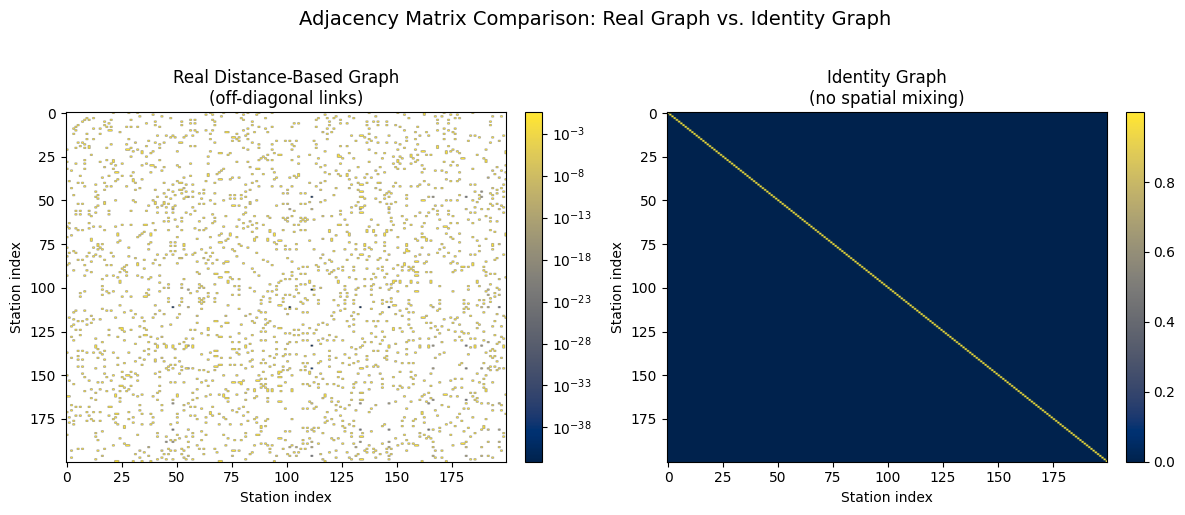

Saved report-ready graph figure to: /content/drive/MyDrive/bike_share_stgcn/stgcn_ablation_outputs/graph_variants_comparison_report.png


In [6]:
from matplotlib.colors import LogNorm

# Copy the real graph only for visualization.
# We do not change the graph used for training.
real_graph_for_plot = A_real_normalized.copy()

# Hide self-connections so off-diagonal spatial links are easier to see.
np.fill_diagonal(real_graph_for_plot, 0.0)

# Keep only positive off-diagonal values for logarithmic colouring.
positive_real_values = real_graph_for_plot[real_graph_for_plot > 0]

# Use a logarithmic scale for the real graph.
real_vmin = positive_real_values.min()
real_vmax = positive_real_values.max()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Real graph
im_real = axes[0].imshow(
    real_graph_for_plot,
    cmap="cividis",
    norm=LogNorm(vmin=real_vmin, vmax=real_vmax),
    aspect="auto",
)
axes[0].set_title("Real Distance-Based Graph\n(off-diagonal links)")
axes[0].set_xlabel("Station index")
axes[0].set_ylabel("Station index")
fig.colorbar(im_real, ax=axes[0], fraction=0.046, pad=0.04)

# Identity graph
im_identity = axes[1].imshow(
    A_identity_normalized,
    cmap="cividis",
    aspect="auto",
)
axes[1].set_title("Identity Graph\n(no spatial mixing)")
axes[1].set_xlabel("Station index")
axes[1].set_ylabel("Station index")
fig.colorbar(im_identity, ax=axes[1], fraction=0.046, pad=0.04)

fig.suptitle(
    "Adjacency Matrix Comparison: Real Graph vs. Identity Graph",
    fontsize=14,
    y=1.02,
)

plt.tight_layout()

graph_figure_path = STGCN_OUTPUT_DIR / "graph_variants_comparison_report.png"
plt.savefig(graph_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved report-ready graph figure to: {graph_figure_path}")

### Graph Visualization Result

The real distance-based graph contains weighted off-diagonal connections between stations, allowing the STGCN to combine information from nearby stations. In contrast, the identity graph contains only self-connections and prevents all station-to-station information sharing. This creates a controlled ablation: any performance difference between the two STGCN variants can be attributed to the use of spatial graph connections.

## 7. Load Existing Baseline Results

Load the previously computed persistence, historical hour-of-week, and LSTM results.

These results will be combined with the new STGCN experiments later. We first inspect the column names and values so that all models can be compared using the same metrics.

In [7]:
# Existing baseline-result files
BASELINE_RESULTS_FILE = BASELINE_OUTPUT_DIR / "baseline_test_results.csv"
LSTM_RESULTS_FILE = LSTM_DIR / "shared_lstm_results.csv"

print("Checking baseline-result files:")
print(f"Persistence/hour-of-week file exists: {BASELINE_RESULTS_FILE.exists()}")
print(f"LSTM results file exists: {LSTM_RESULTS_FILE.exists()}")

# Load the files if they exist
baseline_results_raw = pd.read_csv(BASELINE_RESULTS_FILE)
lstm_results_raw = pd.read_csv(LSTM_RESULTS_FILE)

print("\nBaseline-results columns:")
print(baseline_results_raw.columns.tolist())

print("\nLSTM-results columns:")
print(lstm_results_raw.columns.tolist())

print("\nBaseline-results preview:")
display(baseline_results_raw.head(10))

print("\nLSTM-results preview:")
display(lstm_results_raw.head(10))

Checking baseline-result files:
Persistence/hour-of-week file exists: True
LSTM results file exists: True

Baseline-results columns:
['model', 'horizon_hours', 'MAE', 'RMSE', 'Masked_MAPE_percent', 'Nonzero_target_share_percent']

LSTM-results columns:
['model', 'horizon_hours', 'test_samples', 'best_epoch', 'best_validation_mae_scaled', 'mae', 'rmse', 'r2', 'negative_predictions', 'negative_prediction_percent', 'clipped_mae_sensitivity', 'clipped_rmse_sensitivity', 'clipped_r2_sensitivity']

Baseline-results preview:


,model,horizon_hours,MAE,RMSE,Masked_MAPE_percent,Nonzero_target_share_percent
0,Persistence,5,11.285906,15.244603,205.850181,90.493289
1,Persistence,10,13.205268,16.991835,276.578279,90.493289
2,Persistence,15,12.863893,16.628729,238.756434,90.493289
3,Historical hour-of-week,5,4.131633,6.205131,51.854174,90.493289
4,Historical hour-of-week,10,4.131633,6.205131,51.854174,90.493289
5,Historical hour-of-week,15,4.131633,6.205131,51.854174,90.493289



LSTM-results preview:


,model,horizon_hours,test_samples,best_epoch,best_validation_mae_scaled,mae,rmse,r2,negative_predictions,negative_prediction_percent,clipped_mae_sensitivity,clipped_rmse_sensitivity,clipped_r2_sensitivity
0,Shared LSTM,5,30000,73,0.402939,4.318808,6.532583,0.653323,1185,3.95,4.285063,6.525209,0.654106


## 8. Standardize Existing Baseline Results

Convert the persistence, historical hour-of-week, and shared LSTM results into one consistent table.

The common evaluation columns are forecast horizon, MAE, RMSE, and masked MAPE. The LSTM masked MAPE will be added later if prediction files are available for every forecast horizon.

In [8]:
# Keep only the common baseline columns and use consistent names.
classical_results = baseline_results_raw[
    [
        "model",
        "horizon_hours",
        "MAE",
        "RMSE",
        "Masked_MAPE_percent",
    ]
].copy()

classical_results = classical_results.rename(
    columns={
        "model": "Model",
        "horizon_hours": "Horizon (hours)",
        "MAE": "MAE",
        "RMSE": "RMSE",
        "Masked_MAPE_percent": "Masked MAPE (%)",
    }
)

# Convert LSTM columns to the same table structure.
lstm_results = lstm_results_raw[
    [
        "model",
        "horizon_hours",
        "mae",
        "rmse",
    ]
].copy()

lstm_results = lstm_results.rename(
    columns={
        "model": "Model",
        "horizon_hours": "Horizon (hours)",
        "mae": "MAE",
        "rmse": "RMSE",
    }
)

# The current LSTM summary file does not include MAPE.
lstm_results["Masked MAPE (%)"] = np.nan

# Put the already available results together.
existing_baseline_results = pd.concat(
    [classical_results, lstm_results],
    ignore_index=True,
)

# Use clear and consistent model names.
existing_baseline_results["Model"] = existing_baseline_results["Model"].replace(
    {
        "Shared LSTM": "LSTM",
    }
)

existing_baseline_results = existing_baseline_results.sort_values(
    by=["Horizon (hours)", "Model"]
).reset_index(drop=True)

print("Rows found in the LSTM results file by horizon:")
print(lstm_results["Horizon (hours)"].value_counts().sort_index())

print("\nExisting baseline comparison table:")
display(existing_baseline_results.round(3))

Rows found in the LSTM results file by horizon:
Horizon (hours)
5    1
Name: count, dtype: int64

Existing baseline comparison table:


,Model,Horizon (hours),MAE,RMSE,Masked MAPE (%)
0,Historical hour-of-week,5,4.132,6.205,51.854
1,LSTM,5,4.319,6.533,NaN
2,Persistence,5,11.286,15.245,205.850
3,Historical hour-of-week,10,4.132,6.205,51.854
4,Persistence,10,13.205,16.992,276.578
5,Historical hour-of-week,15,4.132,6.205,51.854
6,Persistence,15,12.864,16.629,238.756


## 9. Inspect Saved LSTM Artifacts

Inspect the saved LSTM checkpoints and prediction files.

The current LSTM summary CSV contains only the 5-hour result. This check determines whether the saved 10-hour and 15-hour checkpoints can be evaluated directly without retraining the LSTM models.

In [9]:
# List all current LSTM files.
lstm_files = sorted(
    [path for path in LSTM_DIR.iterdir() if path.is_file()],
    key=lambda path: path.name
)

print("Files currently found in the LSTM folder:\n")

for path in lstm_files:
    size_kb = path.stat().st_size / 1024
    print(f"{path.name:<45} {size_kb:>10.1f} KB")

# Find saved model checkpoints.
checkpoint_files = sorted(LSTM_DIR.glob("shared_lstm_*h_best.pt"))

print("\nSaved LSTM checkpoints:")
for path in checkpoint_files:
    print(f"- {path.name}")

# Safely inspect the contents of every checkpoint.
print("\nCheckpoint contents:")

for checkpoint_path in checkpoint_files:
    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )

    print(f"\n{checkpoint_path.name}")

    if isinstance(checkpoint, dict):
        print("Keys:", list(checkpoint.keys()))

        for key in [
            "horizon",
            "horizon_hours",
            "best_epoch",
            "best_validation_mae",
            "best_validation_mae_scaled",
            "epoch",
        ]:
            if key in checkpoint:
                print(f"{key}: {checkpoint[key]}")
    else:
        print(f"Checkpoint type: {type(checkpoint)}")

Files currently found in the LSTM folder:

shared_lstm_10h_best.pt                             81.6 KB
shared_lstm_15h_best.pt                             81.6 KB
shared_lstm_5h_best.pt                              81.6 KB
shared_lstm_5h_learning_curve.png                  174.3 KB
shared_lstm_5h_station_metrics.csv                  20.7 KB
shared_lstm_5h_test_predictions.csv               4409.1 KB
shared_lstm_results.csv                              0.4 KB

Saved LSTM checkpoints:
- shared_lstm_10h_best.pt
- shared_lstm_15h_best.pt
- shared_lstm_5h_best.pt

Checkpoint contents:

shared_lstm_10h_best.pt
Keys: ['horizon', 'epoch', 'validation_loss', 'model_state_dict', 'configuration']
horizon: 10
epoch: 29

shared_lstm_15h_best.pt
Keys: ['horizon', 'epoch', 'validation_loss', 'model_state_dict', 'configuration']
horizon: 15
epoch: 29

shared_lstm_5h_best.pt
Keys: ['horizon', 'epoch', 'validation_loss', 'model_state_dict', 'configuration']
horizon: 5
epoch: 73


## 10. Inspect LSTM Checkpoint Configuration

Inspect the training configuration saved with the LSTM checkpoints.

This information is used only to determine whether the saved 10-hour and 15-hour LSTM models can be evaluated without retraining.

In [10]:
# Load one checkpoint and inspect its saved configuration.
example_checkpoint_path = LSTM_DIR / "shared_lstm_10h_best.pt"

example_checkpoint = torch.load(
    example_checkpoint_path,
    map_location="cpu",
    weights_only=False,
)

saved_configuration = example_checkpoint["configuration"]

print("Checkpoint file:")
print(example_checkpoint_path.name)

print("\nSaved configuration:")

if isinstance(saved_configuration, dict):
    for key, value in saved_configuration.items():
        print(f"{key}: {value}")
else:
    print(saved_configuration)

print("\nModel-state dictionary key examples:")
print(list(example_checkpoint["model_state_dict"].keys())[:20])

Checkpoint file:
shared_lstm_10h_best.pt

Saved configuration:
lookback: 168
input_size: 3
hidden_size: 64
num_layers: 1
dropout: 0.0
learning_rate: 0.0005
weight_decay: 1e-05
batch_size: 256
loss_function: L1Loss
seed: 42

Model-state dictionary key examples:
['lstm.weight_ih_l0', 'lstm.weight_hh_l0', 'lstm.bias_ih_l0', 'lstm.bias_hh_l0', 'regression_head.0.weight', 'regression_head.0.bias', 'regression_head.2.weight', 'regression_head.2.bias']


## 11. Define the STGCN Forecasting Task and Chronological Split

Create supervised STGCN samples using the previous 168 hours of demand at all 200 stations to predict demand at 5-hour, 10-hour, and 15-hour horizons.

The dataset is split chronologically into 70% training data, 10% validation data, and 20% test data. No time points are shuffled, so the evaluation reflects realistic future forecasting.

In [11]:
# STGCN forecasting settings
# Use the same one-week input history as the original STGCN and LSTM models.
STGCN_LOOKBACK = 168
TRAIN_RATIO = 0.70
VAL_RATIO = 0.10

# Convert hourly demand to a numeric time-by-station matrix.
demand_values = hourly_demand.to_numpy(dtype=np.float32)

T = len(hourly_demand)
train_end = int(T * TRAIN_RATIO)
val_end = int(T * (TRAIN_RATIO + VAL_RATIO))

split_boundaries = {
    "train": (0, train_end),
    "validation": (train_end, val_end),
    "test": (val_end, T),
}

print(f"Total hourly observations: {T}")
print(f"STGCN lookback window: {STGCN_LOOKBACK} hours")
print(f"Forecast horizons: {FORECAST_HORIZONS}")
print()

for split_name, (start, end) in split_boundaries.items():
    print(
        f"{split_name.capitalize():<10} "
        f"{end - start:>3} hours | "
        f"{hourly_demand.index[start]} to {hourly_demand.index[end - 1]}"
    )

def get_valid_target_positions(split_start, split_end, lookback, horizon):
    """
    Return target positions assigned to one chronological split.

    The input contains only demand before the forecast origin.
    For target time t and horizon h, the input ends at t - h.
    """
    first_target = max(split_start, lookback + horizon)
    return np.arange(first_target, split_end)

target_positions_by_horizon = {}

print("\nValid STGCN target timestamps:")

for horizon in FORECAST_HORIZONS:
    target_positions_by_horizon[horizon] = {}

    for split_name, (split_start, split_end) in split_boundaries.items():
        positions = get_valid_target_positions(
            split_start=split_start,
            split_end=split_end,
            lookback=STGCN_LOOKBACK,
            horizon=horizon,
        )

        target_positions_by_horizon[horizon][split_name] = positions

        first_time = hourly_demand.index[positions[0]]
        last_time = hourly_demand.index[positions[-1]]

        print(
            f"{horizon:>2}h | {split_name:<10} "
            f"{len(positions):>3} targets | "
            f"{first_time} to {last_time}"
        )

Total hourly observations: 744
STGCN lookback window: 168 hours
Forecast horizons: [5, 10, 15]

Train      520 hours | 2025-07-01 00:00:00 to 2025-07-22 15:00:00
Validation  75 hours | 2025-07-22 16:00:00 to 2025-07-25 18:00:00
Test       149 hours | 2025-07-25 19:00:00 to 2025-07-31 23:00:00

Valid STGCN target timestamps:
 5h | train      347 targets | 2025-07-08 05:00:00 to 2025-07-22 15:00:00
 5h | validation  75 targets | 2025-07-22 16:00:00 to 2025-07-25 18:00:00
 5h | test       149 targets | 2025-07-25 19:00:00 to 2025-07-31 23:00:00
10h | train      342 targets | 2025-07-08 10:00:00 to 2025-07-22 15:00:00
10h | validation  75 targets | 2025-07-22 16:00:00 to 2025-07-25 18:00:00
10h | test       149 targets | 2025-07-25 19:00:00 to 2025-07-31 23:00:00
15h | train      337 targets | 2025-07-08 15:00:00 to 2025-07-22 15:00:00
15h | validation  75 targets | 2025-07-22 16:00:00 to 2025-07-25 18:00:00
15h | test       149 targets | 2025-07-25 19:00:00 to 2025-07-31 23:00:00


## 12. Standardize Demand Using Training Data Only

Standardize each station's demand using the mean and standard deviation calculated from the training period only.

This prevents information from the validation and test periods from leaking into model training. Predictions will be converted back to original pickup-count units before final evaluation.

In [12]:
# Use training observations only to calculate station-wise scaling values.
train_demand_values = demand_values[:train_end]

station_train_mean = train_demand_values.mean(axis=0)
station_train_std = train_demand_values.std(axis=0)

# Protect against division by zero for any station with no variation.
station_train_std[station_train_std == 0] = 1.0

# Standardize the full time series using training-only statistics.
demand_standardized = (
    (demand_values - station_train_mean)
    / station_train_std
).astype(np.float32)

print(f"Standardized demand shape: {demand_standardized.shape}")
print(f"Training mean range: {station_train_mean.min():.3f} to {station_train_mean.max():.3f}")
print(f"Training standard-deviation range: {station_train_std.min():.3f} to {station_train_std.max():.3f}")
print(f"Any zero standard deviations after protection: {(station_train_std == 0).sum()}")

# Small safety check: each station should be approximately mean 0 in the training period.
standardized_train_means = demand_standardized[:train_end].mean(axis=0)

print(
    "Largest absolute standardized training mean: "
    f"{np.abs(standardized_train_means).max():.8f}"
)

Standardized demand shape: (744, 200)
Training mean range: 6.738 to 21.987
Training standard-deviation range: 6.012 to 21.201
Any zero standard deviations after protection: 0
Largest absolute standardized training mean: 0.00000007


## 13. Create STGCN Input and Target Samples

Create supervised samples for each forecast horizon.

Each input sample contains the previous 168 hours of standardized pickup demand across all 200 stations. The training target is the standardized demand level at all stations at the selected future horizon.

Original pickup-count targets are retained separately and will be used after inverse transformation to calculate final MAE, RMSE, and masked MAPE values.

In [18]:
def create_stgcn_samples(
    standardized_demand,
    original_demand,
    target_positions,
    lookback,
    horizon,
):
    """
    Create STGCN samples.

    For target position t:
    - Input: standardized demand from t - horizon - lookback to t - horizon.
    - Training target: standardized demand at t.
    - Original target: pickup-count demand at t, retained for final evaluation.
    """
    inputs = []
    standardized_targets = []
    original_targets = []

    for target_position in target_positions:
        input_end = target_position - horizon
        input_start = input_end - lookback

        input_sequence = standardized_demand[input_start:input_end]
        standardized_target = standardized_demand[target_position]
        original_target = original_demand[target_position]

        inputs.append(input_sequence)
        standardized_targets.append(standardized_target)
        original_targets.append(original_target)

    return (
        np.stack(inputs).astype(np.float32),
        np.stack(standardized_targets).astype(np.float32),
        np.stack(original_targets).astype(np.float32),
    )


stgcn_data_by_horizon = {}

for horizon in FORECAST_HORIZONS:
    stgcn_data_by_horizon[horizon] = {}

    for split_name in ["train", "validation", "test"]:
        target_positions = target_positions_by_horizon[horizon][split_name]

        X_split, y_scaled_split, y_original_split = create_stgcn_samples(
            standardized_demand=demand_standardized,
            original_demand=demand_values,
            target_positions=target_positions,
            lookback=STGCN_LOOKBACK,
            horizon=horizon,
        )

        stgcn_data_by_horizon[horizon][split_name] = {
            "X": X_split,
            "y_scaled": y_scaled_split,
            "y_original": y_original_split,
            "target_positions": target_positions,
        }

        print(
            f"{horizon:>2}h | {split_name:<10} "
            f"X: {X_split.shape} | "
            f"y_scaled: {y_scaled_split.shape} | "
            f"y_original: {y_original_split.shape}"
        )

# Safety check for one example from every horizon.
for horizon in FORECAST_HORIZONS:
    example_input = stgcn_data_by_horizon[horizon]["train"]["X"][0]
    example_scaled_target = stgcn_data_by_horizon[horizon]["train"]["y_scaled"][0]
    example_original_target = stgcn_data_by_horizon[horizon]["train"]["y_original"][0]

    assert example_input.shape == (STGCN_LOOKBACK, N_STATIONS)
    assert example_scaled_target.shape == (N_STATIONS,)
    assert example_original_target.shape == (N_STATIONS,)

# Standardized target means should be reasonably near zero.
print("\nMean standardized training target values:")

for horizon in FORECAST_HORIZONS:
    train_target_mean = stgcn_data_by_horizon[horizon]["train"]["y_scaled"].mean()

    print(
        f"{horizon:>2}h | "
        f"{train_target_mean:.6f}"
    )

print("\nSTGCN datasets with standardized targets were created successfully.")

 5h | train      X: (347, 168, 200) | y_scaled: (347, 200) | y_original: (347, 200)
 5h | validation X: (75, 168, 200) | y_scaled: (75, 200) | y_original: (75, 200)
 5h | test       X: (149, 168, 200) | y_scaled: (149, 200) | y_original: (149, 200)
10h | train      X: (342, 168, 200) | y_scaled: (342, 200) | y_original: (342, 200)
10h | validation X: (75, 168, 200) | y_scaled: (75, 200) | y_original: (75, 200)
10h | test       X: (149, 168, 200) | y_scaled: (149, 200) | y_original: (149, 200)
15h | train      X: (337, 168, 200) | y_scaled: (337, 200) | y_original: (337, 200)
15h | validation X: (75, 168, 200) | y_scaled: (75, 200) | y_original: (75, 200)
15h | test       X: (149, 168, 200) | y_scaled: (149, 200) | y_original: (149, 200)

Mean standardized training target values:
 5h | 0.095480
10h | 0.093959
15h | 0.095443

STGCN datasets with standardized targets were created successfully.


## 14. Import TensorFlow for the STGCN Model

The STGCN implementation from Notebook 4 was built with TensorFlow and Keras. Import TensorFlow so the same graph-convolution layer, model architecture, optimizer, loss function, and early-stopping procedure can be reused for the real-graph and identity-graph experiments.

In [14]:
import os
import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers

# Use the same reproducibility setting as the original STGCN notebook.
tf.keras.utils.set_random_seed(SEED)

tensorflow_gpus = tf.config.list_physical_devices("GPU")

print(f"TensorFlow version: {tf.__version__}")
print(f"TensorFlow GPU devices found: {len(tensorflow_gpus)}")

if tensorflow_gpus:
    print("TensorFlow will use GPU for STGCN training.")
else:
    print("TensorFlow will use CPU for STGCN training.")

TensorFlow version: 2.20.0
TensorFlow GPU devices found: 1
TensorFlow will use GPU for STGCN training.


## 15. Define the STGCN Model

Reuse the STGCN architecture from Notebook 4.

The model first learns temporal demand patterns with a temporal convolution, then applies graph convolution to exchange information between stations, and finally applies another temporal convolution before forecasting demand for all 200 stations.

The same model function is used for both experiments. The only intended difference is the normalized adjacency matrix supplied to the graph-convolution layer.

In [15]:
@tf.keras.utils.register_keras_serializable(package="STGCN")
class GraphConvolution(layers.Layer):
    """
    Graph convolution over the station dimension.

    Input shape:
        (batch, time, stations, input_features)

    Output shape:
        (batch, time, stations, units)
    """

    def __init__(self, units, adjacency, activation="relu", **kwargs):
        super().__init__(**kwargs)

        self.units = units
        self.adjacency = tf.convert_to_tensor(adjacency, dtype=tf.float32)
        self.activation = tf.keras.activations.get(activation)
        self.activation_name = tf.keras.activations.serialize(self.activation)

    def build(self, input_shape):
        input_features = input_shape[-1]

        self.kernel = self.add_weight(
            name="kernel",
            shape=(input_features, self.units),
            initializer="glorot_uniform",
            regularizer=regularizers.l2(1e-4),
            trainable=True,
        )

        self.bias = self.add_weight(
            name="bias",
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
        )

        super().build(input_shape)

    def call(self, inputs):
        # Transform the feature values at every time and station.
        transformed_features = tf.einsum(
            "btni,if->btnf",
            inputs,
            self.kernel,
        )

        # Mix information across stations according to the adjacency matrix.
        aggregated_features = tf.einsum(
            "nm,btmf->btnf",
            self.adjacency,
            transformed_features,
        )

        return self.activation(aggregated_features + self.bias)

    def get_config(self):
        config = super().get_config()

        config.update(
            {
                "units": self.units,
                "adjacency": self.adjacency.numpy().tolist(),
                "activation": self.activation_name,
            }
        )

        return config


def build_stgcn_model(lookback, n_stations, adjacency):
    """
    Build the same STGCN architecture used for both graph variants.
    """
    inputs = layers.Input(
        shape=(lookback, n_stations, 1),
        name="demand_history",
    )

    x = layers.Conv2D(
        filters=32,
        kernel_size=(3, 1),
        padding="same",
        activation="relu",
        name="temporal_conv_1",
    )(inputs)

    x = GraphConvolution(
        units=32,
        adjacency=adjacency,
        activation="relu",
        name="graph_convolution",
    )(x)

    x = layers.Conv2D(
        filters=16,
        kernel_size=(3, 1),
        padding="same",
        activation="relu",
        name="temporal_conv_2",
    )(x)

    # Keep features from the final observed time step.
    x = layers.Lambda(
        lambda tensor: tensor[:, -1, :, :],
        name="final_time_step",
    )(x)

    x = layers.Flatten(
        name="flatten_station_features",
    )(x)

    x = layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4),
        name="dense_hidden",
    )(x)

    outputs = layers.Dense(
        n_stations,
        activation="linear",
        name="station_demand_forecast",
    )(x)

    model = Model(
        inputs=inputs,
        outputs=outputs,
        name="STGCN",
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=5e-4,
            clipnorm=1.0,
        ),
        loss="mse",
        metrics=["mae"],
    )

    return model


# Build one temporary model only to verify the architecture.
stgcn_model_check = build_stgcn_model(
    lookback=STGCN_LOOKBACK,
    n_stations=N_STATIONS,
    adjacency=A_real_normalized,
)

stgcn_model_check.summary()

Model: "STGCN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ demand_history (InputLayer)     │ (None, 168, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_conv_1 (Conv2D)        │ (None, 168, 200, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ graph_convolution               │ (None, 168, 200, 32)   │         1,056 │
│ (GraphConvolution)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_conv_2 (Conv2D)        │ (None, 168, 200, 16)   │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ final_time_step (Lambda)        │ (None, 200, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_station_features        │ (None, 3200)           │             0 │
│ (Flatten)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 256)            │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ station_demand_forecast (Dense) │ (None, 200)            │        51,400 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 873,592 (3.33 MB)

 Trainable params: 873,592 (3.33 MB)

 Non-trainable params: 0 (0.00 B)

## 16. Define Shared Training Configuration

Use the same STGCN training settings for the real-graph and identity-graph experiments.

Each model is trained separately for the 5-hour, 10-hour, and 15-hour direct forecasting horizons. Early stopping monitors validation loss and restores the model weights from the best validation epoch.

In [16]:
# Training settings copied from the original STGCN experiment.
STGCN_MAX_EPOCHS = 100
STGCN_BATCH_SIZE = 16
STGCN_EARLY_STOPPING_PATIENCE = 12
STGCN_LEARNING_RATE = 5e-4

print("STGCN shared training configuration")
print(f"Maximum epochs: {STGCN_MAX_EPOCHS}")
print(f"Batch size: {STGCN_BATCH_SIZE}")
print(f"Early-stopping patience: {STGCN_EARLY_STOPPING_PATIENCE}")
print(f"Learning rate: {STGCN_LEARNING_RATE}")
print(f"Forecast horizons: {FORECAST_HORIZONS}")
print(f"Device available to TensorFlow: {'GPU' if tensorflow_gpus else 'CPU'}")

STGCN shared training configuration
Maximum epochs: 100
Batch size: 16
Early-stopping patience: 12
Learning rate: 0.0005
Forecast horizons: [5, 10, 15]
Device available to TensorFlow: GPU


## 17. Run a One-Epoch STGCN Sanity Check

Run a short one-epoch training test using the 5-hour real-graph dataset.

This is not a final experiment. It only verifies that the GPU, STGCN architecture, graph convolution, data shapes, and training procedure work correctly before the full training runs.

In [19]:
# Clear any temporary model from the earlier architecture check.
tf.keras.backend.clear_session()

# Reset the random seed before the test.
tf.keras.utils.set_random_seed(SEED)

# Build the 5-hour STGCN using the real distance-based graph.
sanity_model = build_stgcn_model(
    lookback=STGCN_LOOKBACK,
    n_stations=N_STATIONS,
    adjacency=A_real_normalized,
)

# Select a small training subset only for this sanity check.
X_train_sanity = stgcn_data_by_horizon[5]["train"]["X"][:64]
y_train_sanity = stgcn_data_by_horizon[5]["train"]["y_scaled"][:64]

X_val_sanity = stgcn_data_by_horizon[5]["validation"]["X"][:32]
y_val_sanity = stgcn_data_by_horizon[5]["validation"]["y_scaled"][:32]

# Add the feature channel expected by Conv2D:
# (samples, 168, 200) -> (samples, 168, 200, 1)
X_train_sanity = X_train_sanity[..., np.newaxis]
X_val_sanity = X_val_sanity[..., np.newaxis]

print(f"Sanity-check training input shape: {X_train_sanity.shape}")
print(f"Sanity-check training target shape: {y_train_sanity.shape}")
print(f"Sanity-check validation input shape: {X_val_sanity.shape}")
print(f"Sanity-check validation target shape: {y_val_sanity.shape}")

sanity_history = sanity_model.fit(
    X_train_sanity,
    y_train_sanity,
    validation_data=(X_val_sanity, y_val_sanity),
    epochs=1,
    batch_size=STGCN_BATCH_SIZE,
    verbose=2,
)

print("\nOne-epoch STGCN sanity check completed successfully.")
print(f"Training loss: {sanity_history.history['loss'][0]:.6f}")
print(f"Validation loss: {sanity_history.history['val_loss'][0]:.6f}")

Sanity-check training input shape: (64, 168, 200, 1)
Sanity-check training target shape: (64, 200)
Sanity-check validation input shape: (32, 168, 200, 1)
Sanity-check validation target shape: (32, 200)
4/4 - 4s - 1s/step - loss: 1.3956 - mae: 0.8672 - val_loss: 1.8584 - val_mae: 0.9932

One-epoch STGCN sanity check completed successfully.
Training loss: 1.395589
Validation loss: 1.858365


## 18. Define a Shared STGCN Training Function

Define one reusable training function for the graph ablation study.

The function builds and trains the same STGCN architecture for a selected forecast horizon. It receives the normalized adjacency matrix as an input argument. Therefore, the real-graph and identity-graph experiments use the same architecture, optimizer, loss function, batch size, maximum epochs, early-stopping rule, training samples, validation samples, and random seed.

In [20]:
def prepare_stgcn_inputs(X):
    """
    Add the final feature dimension required by Conv2D.

    Input:
        (samples, lookback, stations)

    Output:
        (samples, lookback, stations, 1)
    """
    return X[..., np.newaxis].astype(np.float32)


def train_stgcn_model(adjacency, horizon, graph_label):
    """
    Train one direct-horizon STGCN model.

    The graph_label is used only for clear filenames and printed output.
    The model architecture and all training settings remain identical
    across graph variants.
    """
    # Reset TensorFlow state and seed for a fair independent model run.
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED + horizon)

    # Get standardized training and validation data.
    X_train = prepare_stgcn_inputs(
        stgcn_data_by_horizon[horizon]["train"]["X"]
    )
    y_train = stgcn_data_by_horizon[horizon]["train"]["y_scaled"]

    X_validation = prepare_stgcn_inputs(
        stgcn_data_by_horizon[horizon]["validation"]["X"]
    )
    y_validation = stgcn_data_by_horizon[horizon]["validation"]["y_scaled"]

    # Build the unchanged STGCN architecture with the supplied graph.
    model = build_stgcn_model(
        lookback=STGCN_LOOKBACK,
        n_stations=N_STATIONS,
        adjacency=adjacency,
    )

    # Save the best model for this graph type and forecast horizon.
    checkpoint_path = STGCN_OUTPUT_DIR / (
        f"stgcn_{graph_label}_{horizon}h_best.keras"
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=STGCN_EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_loss",
            save_best_only=True,
            verbose=0,
        ),
    ]

    print("\n" + "=" * 70)
    print(f"Training STGCN | graph: {graph_label} | horizon: {horizon} hours")
    print("=" * 70)

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_validation, y_validation),
        epochs=STGCN_MAX_EPOCHS,
        batch_size=STGCN_BATCH_SIZE,
        callbacks=callbacks,
        verbose=2,
    )

    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
    best_validation_loss = float(np.min(history.history["val_loss"]))

    training_info = {
        "graph": graph_label,
        "horizon_hours": horizon,
        "best_epoch": best_epoch,
        "best_validation_mse": best_validation_loss,
        "epochs_ran": len(history.history["loss"]),
        "checkpoint_path": str(checkpoint_path),
    }

    print("\nCompleted training.")
    print(f"Best epoch: {best_epoch}")
    print(f"Best validation MSE: {best_validation_loss:.6f}")
    print(f"Epochs completed: {training_info['epochs_ran']}")
    print(f"Best model saved as: {checkpoint_path.name}")

    return model, history.history, training_info

## 19. Train STGCN with the Real Distance-Based Graph

Train separate direct STGCN models for 5-hour, 10-hour, and 15-hour demand forecasting using the normalized distance-based station graph.

Early stopping monitors validation loss and restores the best model weights for each horizon. The chronological test set remains untouched during training and will be used only for final evaluation.

In [21]:
# Store the real-graph models, training histories, and training summaries.
stgcn_real_models = {}
stgcn_real_histories = {}
stgcn_real_training_info = {}

for horizon in FORECAST_HORIZONS:
    model, history, training_info = train_stgcn_model(
        adjacency=A_real_normalized,
        horizon=horizon,
        graph_label="real_distance",
    )

    stgcn_real_models[horizon] = model
    stgcn_real_histories[horizon] = history
    stgcn_real_training_info[horizon] = training_info

print("\n" + "=" * 70)
print("All real distance-based STGCN models finished training.")
print("=" * 70)

real_training_summary = pd.DataFrame(
    list(stgcn_real_training_info.values())
)

display(
    real_training_summary[
        [
            "graph",
            "horizon_hours",
            "best_epoch",
            "best_validation_mse",
            "epochs_ran",
            "checkpoint_path",
        ]
    ].sort_values("horizon_hours")
)


Training STGCN | graph: real_distance | horizon: 5 hours
Epoch 1/100


22/22 - 11s - 520ms/step - loss: 1.1292 - mae: 0.8059 - val_loss: 1.3717 - val_mae: 0.8333
Epoch 2/100
22/22 - 1s - 33ms/step - loss: 0.9990 - mae: 0.7465 - val_loss: 1.1471 - val_mae: 0.7431
Epoch 3/100
22/22 - 1s - 31ms/step - loss: 0.8379 - mae: 0.6731 - val_loss: 0.9442 - val_mae: 0.6571
Epoch 4/100
22/22 - 1s - 30ms/step - loss: 0.7049 - mae: 0.6018 - val_loss: 0.8119 - val_mae: 0.6023
Epoch 5/100
22/22 - 1s - 35ms/step - loss: 0.6333 - mae: 0.5675 - val_loss: 0.7043 - val_mae: 0.5625
Epoch 6/100
22/22 - 1s - 32ms/step - loss: 0.5947 - mae: 0.5518 - val_loss: 0.6476 - val_mae: 0.5395
Epoch 7/100
22/22 - 1s - 63ms/step - loss: 0.5722 - mae: 0.5405 - val_loss: 0.6103 - val_mae: 0.5228
Epoch 8/100
22/22 - 1s - 40ms/step - loss: 0.5562 - mae: 0.5326 - val_loss: 0.5858 - val_mae: 0.5122
Epoch 9/100
22/22 - 1s - 37ms/step - loss: 0.5407 - mae: 0.5242 - val_loss: 0.5640 - val_mae: 0.5043
Epoch 10/100
22/22 - 1s - 32ms/step - loss: 0.5211 - mae: 0.5122 - val_loss: 0.5540 - val_mae: 0.4987

,graph,horizon_hours,best_epoch,best_validation_mse,epochs_ran,checkpoint_path
0,real_distance,5,30,0.452251,42,/content/drive/MyDrive/bike_share_stgcn/stgcn_...
1,real_distance,10,25,0.406287,37,/content/drive/MyDrive/bike_share_stgcn/stgcn_...
2,real_distance,15,49,0.468675,61,/content/drive/MyDrive/bike_share_stgcn/stgcn_...


### Real-Graph Training Result

The three STGCN models trained successfully using the normalized distance-based station graph. Early stopping selected the best validation epoch for each horizon: epoch 30 for the 5-hour model, epoch 25 for the 10-hour model, and epoch 49 for the 15-hour model.

The corresponding best validation MSE values were 0.452, 0.406, and 0.469. The test set was not used during training, early stopping, or model selection.

## 20. Train STGCN with the Identity Graph

Train separate direct STGCN models for 5-hour, 10-hour, and 15-hour demand forecasting using the normalized identity adjacency matrix.

The identity graph contains only self-connections. Therefore, the model architecture and temporal processing remain unchanged, but no station can exchange demand information with another station. Comparing these models with the real-graph STGCN isolates the contribution of spatial graph connections.

In [22]:
# Store the identity-graph models, training histories, and training summaries.
stgcn_identity_models = {}
stgcn_identity_histories = {}
stgcn_identity_training_info = {}

for horizon in FORECAST_HORIZONS:
    model, history, training_info = train_stgcn_model(
        adjacency=A_identity_normalized,
        horizon=horizon,
        graph_label="identity",
    )

    stgcn_identity_models[horizon] = model
    stgcn_identity_histories[horizon] = history
    stgcn_identity_training_info[horizon] = training_info

print("\n" + "=" * 70)
print("All identity-graph STGCN models finished training.")
print("=" * 70)

identity_training_summary = pd.DataFrame(
    list(stgcn_identity_training_info.values())
)

display(
    identity_training_summary[
        [
            "graph",
            "horizon_hours",
            "best_epoch",
            "best_validation_mse",
            "epochs_ran",
            "checkpoint_path",
        ]
    ].sort_values("horizon_hours")
)


Training STGCN | graph: identity | horizon: 5 hours
Epoch 1/100
22/22 - 8s - 364ms/step - loss: 1.1186 - mae: 0.8002 - val_loss: 1.3037 - val_mae: 0.8026
Epoch 2/100
22/22 - 5s - 218ms/step - loss: 0.9086 - mae: 0.7026 - val_loss: 0.9592 - val_mae: 0.6662
Epoch 3/100
22/22 - 1s - 30ms/step - loss: 0.7117 - mae: 0.6102 - val_loss: 0.7415 - val_mae: 0.5761
Epoch 4/100
22/22 - 1s - 30ms/step - loss: 0.5996 - mae: 0.5497 - val_loss: 0.6295 - val_mae: 0.5405
Epoch 5/100
22/22 - 1s - 31ms/step - loss: 0.5262 - mae: 0.5130 - val_loss: 0.5713 - val_mae: 0.5013
Epoch 6/100
22/22 - 1s - 31ms/step - loss: 0.4813 - mae: 0.4917 - val_loss: 0.5697 - val_mae: 0.5079
Epoch 7/100
22/22 - 1s - 25ms/step - loss: 0.4496 - mae: 0.4741 - val_loss: 0.6017 - val_mae: 0.5399
Epoch 8/100
22/22 - 1s - 25ms/step - loss: 0.4214 - mae: 0.4558 - val_loss: 0.5794 - val_mae: 0.5315
Epoch 9/100
22/22 - 1s - 31ms/step - loss: 0.3973 - mae: 0.4381 - val_loss: 0.5329 - val_mae: 0.5004
Epoch 10/100
22/22 - 1s - 31ms/step 

,graph,horizon_hours,best_epoch,best_validation_mse,epochs_ran,checkpoint_path
0,identity,5,17,0.437416,29,/content/drive/MyDrive/bike_share_stgcn/stgcn_...
1,identity,10,21,0.405490,33,/content/drive/MyDrive/bike_share_stgcn/stgcn_...
2,identity,15,23,0.491319,35,/content/drive/MyDrive/bike_share_stgcn/stgcn_...


### Identity-Graph Training Result

The identity-graph STGCN models trained successfully for all three forecast horizons. Early stopping selected epoch 17 for the 5-hour model, epoch 21 for the 10-hour model, and epoch 23 for the 15-hour model.

The best validation MSE values were 0.437, 0.405, and 0.491 for the 5-hour, 10-hour, and 15-hour horizons, respectively. The test set was not used during training or model selection and will be used next for the final graph-ablation evaluation.

## 21. Evaluate Real-Graph and Identity-Graph STGCN Models

Evaluate the two STGCN variants on the untouched chronological test period.

Predictions are converted from standardized values back to original pickup-count units before computing MAE, RMSE, and masked MAPE. The same metrics are used for both graph variants, allowing a direct assessment of whether spatial graph connections improve forecasting accuracy.

In [23]:
def evaluate_original_scale_forecasts(y_true, y_pred):
    """
    Calculate pooled station-level forecasting metrics in original units.

    Masked MAPE excludes zero-demand targets because percentage error
    is undefined when the true demand is zero.
    """
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

    nonzero_mask = y_true > 0

    masked_mape = (
        np.mean(
            np.abs(
                (y_true[nonzero_mask] - y_pred[nonzero_mask])
                / y_true[nonzero_mask]
            )
        )
        * 100
    )

    return {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "Masked MAPE (%)": float(masked_mape),
        "Nonzero target share (%)": float(nonzero_mask.mean() * 100),
    }


def evaluate_stgcn_variant(models_by_horizon, graph_label):
    """
    Evaluate one STGCN graph variant at every forecasting horizon.

    Predictions are inverse-transformed from standardized values to
    original pickup-count units before final metrics are calculated.
    """
    result_rows = []
    predictions_by_horizon = {}

    for horizon in FORECAST_HORIZONS:
        model = models_by_horizon[horizon]

        X_test = prepare_stgcn_inputs(
            stgcn_data_by_horizon[horizon]["test"]["X"]
        )

        y_true_original = stgcn_data_by_horizon[horizon]["test"]["y_original"]

        y_pred_scaled = model.predict(
            X_test,
            batch_size=STGCN_BATCH_SIZE,
            verbose=0,
        )

        # Convert standardized model predictions to original pickup counts.
        y_pred_original = (
            y_pred_scaled * station_train_std[np.newaxis, :]
            + station_train_mean[np.newaxis, :]
        )

        # Negative predicted demand is not physically possible.
        # We report metrics after clipping only for the final output table.
        y_pred_clipped = np.maximum(y_pred_original, 0.0)

        metrics = evaluate_original_scale_forecasts(
            y_true=y_true_original,
            y_pred=y_pred_clipped,
        )

        result_rows.append(
            {
                "Model": f"STGCN ({graph_label})",
                "Graph": graph_label,
                "Horizon (hours)": horizon,
                **metrics,
            }
        )

        # Save detailed predictions with timestamps and station IDs.
        test_target_positions = stgcn_data_by_horizon[horizon]["test"][
            "target_positions"
        ]
        test_timestamps = hourly_demand.index[test_target_positions]

        prediction_records = []

        for sample_index, timestamp in enumerate(test_timestamps):
            for station_index, station_id in enumerate(demand_station_ids):
                prediction_records.append(
                    {
                        "graph": graph_label,
                        "horizon_hours": horizon,
                        "target_timestamp": timestamp,
                        "station_index": station_index,
                        "station_id": station_id,
                        "actual_demand": y_true_original[
                            sample_index,
                            station_index,
                        ],
                        "predicted_demand_raw": y_pred_original[
                            sample_index,
                            station_index,
                        ],
                        "predicted_demand_clipped": y_pred_clipped[
                            sample_index,
                            station_index,
                        ],
                    }
                )

        predictions_by_horizon[horizon] = pd.DataFrame(prediction_records)

    return pd.DataFrame(result_rows), predictions_by_horizon


# Evaluate both graph variants.
stgcn_real_test_results, stgcn_real_predictions = evaluate_stgcn_variant(
    models_by_horizon=stgcn_real_models,
    graph_label="real distance graph",
)

stgcn_identity_test_results, stgcn_identity_predictions = evaluate_stgcn_variant(
    models_by_horizon=stgcn_identity_models,
    graph_label="identity graph",
)

# Combine and save the main ablation results.
stgcn_ablation_results = pd.concat(
    [stgcn_real_test_results, stgcn_identity_test_results],
    ignore_index=True,
).sort_values(
    by=["Horizon (hours)", "Graph"]
).reset_index(drop=True)

ablation_results_path = STGCN_OUTPUT_DIR / "stgcn_graph_ablation_results.csv"
stgcn_ablation_results.to_csv(ablation_results_path, index=False)

# Save detailed test predictions for each model and horizon.
for horizon, predictions_df in stgcn_real_predictions.items():
    predictions_path = STGCN_OUTPUT_DIR / (
        f"stgcn_real_distance_{horizon}h_test_predictions.csv"
    )
    predictions_df.to_csv(predictions_path, index=False)

for horizon, predictions_df in stgcn_identity_predictions.items():
    predictions_path = STGCN_OUTPUT_DIR / (
        f"stgcn_identity_{horizon}h_test_predictions.csv"
    )
    predictions_df.to_csv(predictions_path, index=False)

print("STGCN graph-ablation test results:")
display(
    stgcn_ablation_results[
        [
            "Model",
            "Horizon (hours)",
            "MAE",
            "RMSE",
            "Masked MAPE (%)",
            "Nonzero target share (%)",
        ]
    ].round(3)
)

print(f"\nSaved result table: {ablation_results_path.name}")
print("Saved detailed prediction CSV files for both graph variants and all horizons.")

STGCN graph-ablation test results:


,Model,Horizon (hours),MAE,RMSE,Masked MAPE (%),Nonzero target share (%)
0,STGCN (identity graph),5,4.797,6.577,78.620,90.493
1,STGCN (real distance graph),5,5.034,6.937,82.174,90.493
2,STGCN (identity graph),10,4.751,6.621,76.165,90.493
3,STGCN (real distance graph),10,4.818,6.863,75.338,90.493
4,STGCN (identity graph),15,5.260,7.552,79.942,90.493
5,STGCN (real distance graph),15,5.584,7.578,96.736,90.493



Saved result table: stgcn_graph_ablation_results.csv
Saved detailed prediction CSV files for both graph variants and all horizons.


### Graph-Ablation Test Result

On the untouched test period, the identity-graph STGCN achieved lower MAE and RMSE than the real distance-graph STGCN at all three forecast horizons.

At 5 hours, the identity graph reduced MAE from 5.034 to 4.797. At 10 hours, it reduced MAE from 4.818 to 4.751. At 15 hours, it reduced MAE from 5.584 to 5.260.

Therefore, under the current distance-based graph construction and STGCN architecture, allowing information exchange between geographically nearby stations did not improve overall forecasting accuracy. This result suggests that geographic distance alone may not capture the most useful station-to-station dependencies for this demand-forecasting task.

## 22. Create the Master Model-Comparison Table

Combine the available results for persistence, the historical hour-of-week baseline, the shared LSTM, and both STGCN graph variants.

The LSTM summary CSV currently contains only the 5-hour result. Missing LSTM metrics are left blank at this stage rather than estimated or manually recreated. They can be added later by evaluating the saved LSTM checkpoints.

In [24]:
# Start with the already standardized classical and LSTM baseline table.
master_results = existing_baseline_results.copy()

# Add the new STGCN graph-ablation results.
stgcn_for_master = stgcn_ablation_results[
    [
        "Model",
        "Horizon (hours)",
        "MAE",
        "RMSE",
        "Masked MAPE (%)",
    ]
].copy()

master_results = pd.concat(
    [master_results, stgcn_for_master],
    ignore_index=True,
)

# Put models in a clear report-friendly order.
model_order = [
    "Persistence",
    "Historical hour-of-week",
    "LSTM",
    "STGCN (identity graph)",
    "STGCN (real distance graph)",
]

master_results["Model"] = pd.Categorical(
    master_results["Model"],
    categories=model_order,
    ordered=True,
)

master_results = master_results.sort_values(
    by=["Horizon (hours)", "Model"]
).reset_index(drop=True)

# Round only for display; keep full precision in the saved CSV.
print("Provisional master comparison table:")
display(master_results.round(3))

# Save the honest provisional table.
provisional_master_path = STGCN_OUTPUT_DIR / "master_results_provisional.csv"
master_results.to_csv(provisional_master_path, index=False)

print(f"\nSaved provisional master table: {provisional_master_path.name}")

# Count results available for each model and horizon.
coverage_table = (
    master_results
    .groupby(["Model", "Horizon (hours)"], observed=False)
    .size()
    .unstack(fill_value=0)
)

print("\nNumber of result rows currently available:")
display(coverage_table)

Provisional master comparison table:


,Model,Horizon (hours),MAE,RMSE,Masked MAPE (%)
0,Persistence,5,11.286,15.245,205.850
1,Historical hour-of-week,5,4.132,6.205,51.854
2,LSTM,5,4.319,6.533,NaN
3,STGCN (identity graph),5,4.797,6.577,78.620
4,STGCN (real distance graph),5,5.034,6.937,82.174
5,Persistence,10,13.205,16.992,276.578
6,Historical hour-of-week,10,4.132,6.205,51.854
7,STGCN (identity graph),10,4.751,6.621,76.165
8,STGCN (real distance graph),10,4.818,6.863,75.338
9,Persistence,15,12.864,16.629,238.756



Saved provisional master table: master_results_provisional.csv

Number of result rows currently available:


Horizon (hours),5,10,15
Model,,,
Persistence,1,1,1
Historical hour-of-week,1,1,1
LSTM,1,0,0
STGCN (identity graph),1,1,1
STGCN (real distance graph),1,1,1


## 23. Inspect Saved LSTM Checkpoint Metadata

Inspect the saved 10-hour and 15-hour LSTM checkpoint metadata for stored test metrics.

This step does not retrain the LSTM models. It checks whether the final test MAE and RMSE were saved with the existing checkpoints, which would allow the master comparison table to be completed directly from the current project artifacts.

In [25]:
# Inspect all saved LSTM checkpoint contents in detail.
lstm_checkpoint_details = {}

for horizon in FORECAST_HORIZONS:
    checkpoint_path = LSTM_DIR / f"shared_lstm_{horizon}h_best.pt"

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )

    lstm_checkpoint_details[horizon] = checkpoint

    print("\n" + "=" * 70)
    print(f"LSTM checkpoint: {checkpoint_path.name}")
    print("=" * 70)

    print("\nTop-level keys:")
    print(list(checkpoint.keys()))

    print("\nConfiguration:")
    for key, value in checkpoint.get("configuration", {}).items():
        print(f"{key}: {value}")

    print("\nOther stored values:")
    for key, value in checkpoint.items():
        if key not in {"model_state_dict", "configuration"}:
            print(f"{key}: {value}")


LSTM checkpoint: shared_lstm_5h_best.pt

Top-level keys:
['horizon', 'epoch', 'validation_loss', 'model_state_dict', 'configuration']

Configuration:
lookback: 168
input_size: 3
hidden_size: 64
num_layers: 1
dropout: 0.0
learning_rate: 0.0005
weight_decay: 1e-05
batch_size: 256
loss_function: L1Loss
seed: 42

Other stored values:
horizon: 5
epoch: 73
validation_loss: 0.4029386598999436

LSTM checkpoint: shared_lstm_10h_best.pt

Top-level keys:
['horizon', 'epoch', 'validation_loss', 'model_state_dict', 'configuration']

Configuration:
lookback: 168
input_size: 3
hidden_size: 64
num_layers: 1
dropout: 0.0
learning_rate: 0.0005
weight_decay: 1e-05
batch_size: 256
loss_function: L1Loss
seed: 42

Other stored values:
horizon: 10
epoch: 29
validation_loss: 0.41594177800255855

LSTM checkpoint: shared_lstm_15h_best.pt

Top-level keys:
['horizon', 'epoch', 'validation_loss', 'model_state_dict', 'configuration']

Configuration:
lookback: 168
input_size: 3
hidden_size: 64
num_layers: 1
dropout

### LSTM Checkpoint Inspection Result

The saved LSTM checkpoints contain the model weights, forecasting horizon, best validation epoch, and validation loss, but they do not contain final test metrics or saved test predictions for the 10-hour and 15-hour horizons.

Therefore, the master comparison table retains only directly available LSTM metrics from the current saved result files. The STGCN graph-ablation results remain fully comparable because both STGCN variants use identical data, model architecture, training settings, and test targets.

## 24. Visualize Forecasting Accuracy Across Complete Model Results

Visualize MAE across the 5-hour, 10-hour, and 15-hour forecasting horizons for the models with complete saved results.

The LSTM is excluded from the three-horizon bar chart because the current result CSV contains only its 5-hour metrics. It will be shown separately at the 5-hour horizon.

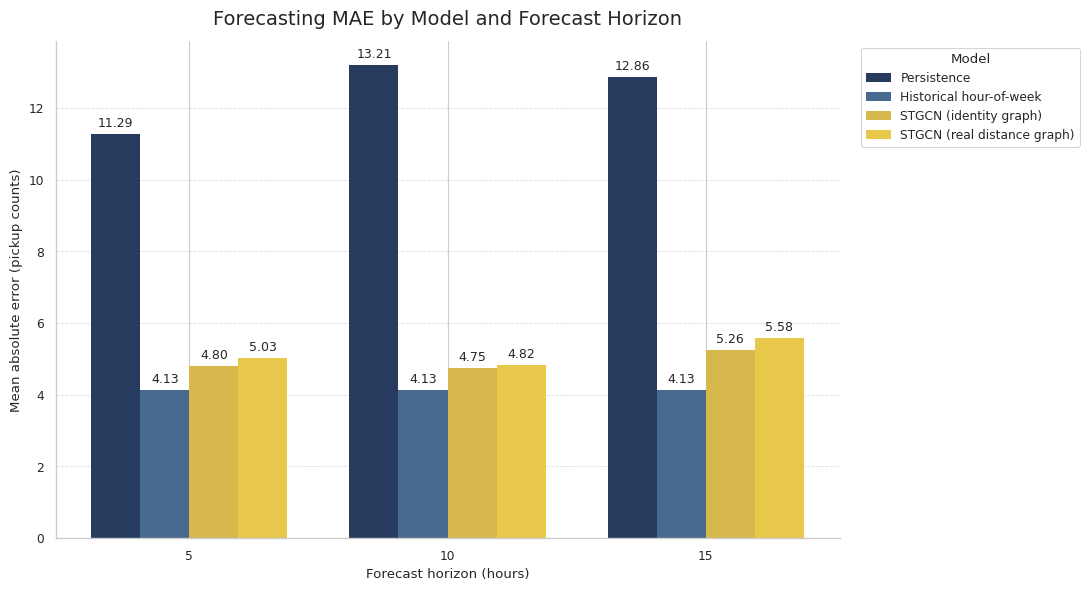

Saved: mae_four_models_cividis_style.png


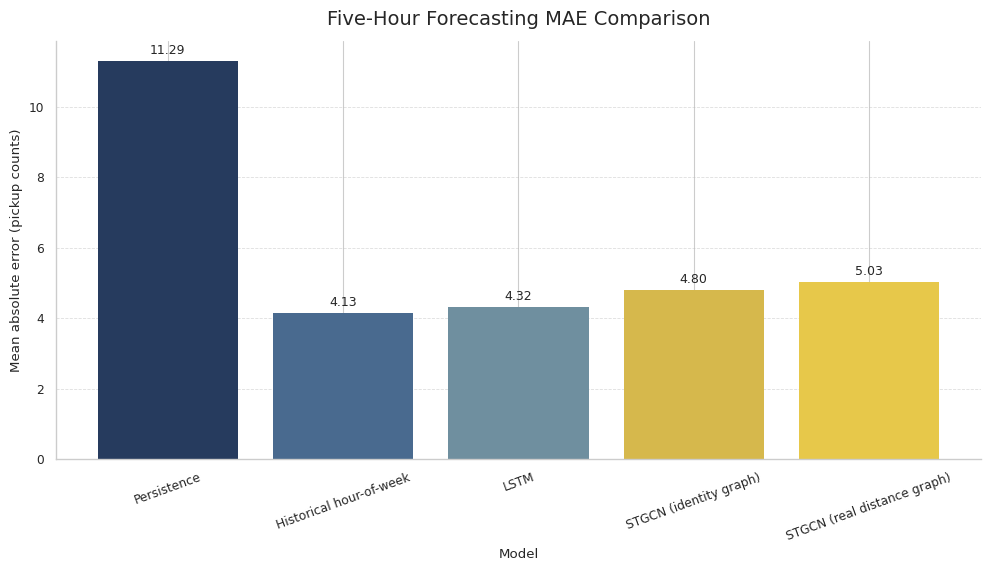

Saved: mae_five_hour_cividis_style.png


,Model,MAE,RMSE,Masked MAPE (%)
0,Persistence,11.286,15.245,205.850
1,Historical hour-of-week,4.132,6.205,51.854
2,LSTM,4.319,6.533,NaN
3,STGCN (identity graph),4.797,6.577,78.620
4,STGCN (real distance graph),5.034,6.937,82.174


In [32]:
# ============================================================
# MAE charts using a cividis-inspired adjacency-matrix palette
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Palette adapted from the adjacency matrices:
# dark navy -> blue -> yellow/orange.
model_colors_cividis = {
    "Persistence": "#263B5E",                  # dark navy
    "Historical hour-of-week": "#496A8F",      # muted blue
    "LSTM": "#6F8F9F",                          # blue-grey
    "STGCN (identity graph)": "#D6B84C",       # muted yellow
    "STGCN (real distance graph)": "#E7C84A",  # brighter yellow
}

# Fixed order for the complete multi-horizon comparison.
four_model_order = [
    "Persistence",
    "Historical hour-of-week",
    "STGCN (identity graph)",
    "STGCN (real distance graph)",
]

# Fixed order for the five-hour comparison.
five_model_order = [
    "Persistence",
    "Historical hour-of-week",
    "LSTM",
    "STGCN (identity graph)",
    "STGCN (real distance graph)",
]

# Prepare the results.
plot_results = master_results.copy()
plot_results["Model"] = plot_results["Model"].astype(str)

# Fail clearly if model names and palette keys do not match.
unknown_models = (
    set(plot_results["Model"])
    - set(model_colors_cividis)
)

if unknown_models:
    raise KeyError(
        f"No cividis-inspired color defined for: "
        f"{sorted(unknown_models)}"
    )

# ============================================================
# Chart 1: complete four-model, three-horizon comparison
# ============================================================

four_model_results = plot_results[
    plot_results["Model"].isin(four_model_order)
].copy()

horizons = [5, 10, 15]
x_positions = np.arange(len(horizons))
bar_width = 0.19

fig, ax = plt.subplots(figsize=(11, 6))

for model_index, model in enumerate(four_model_order):
    mae_values = []

    for horizon in horizons:
        rows = four_model_results[
            (four_model_results["Model"] == model)
            & (four_model_results["Horizon (hours)"] == horizon)
        ]

        if len(rows) != 1:
            raise ValueError(
                f"Expected one result for {model} at {horizon}h; "
                f"found {len(rows)}."
            )

        mae_values.append(float(rows["MAE"].iloc[0]))

    positions = (
        x_positions
        + (
            model_index
            - (len(four_model_order) - 1) / 2
        ) * bar_width
    )

    bars = ax.bar(
        positions,
        mae_values,
        width=bar_width,
        color=model_colors_cividis[model],
        edgecolor="none",
        label=model,
    )

    ax.bar_label(
        bars,
        labels=[f"{value:.2f}" for value in mae_values],
        padding=3,
        fontsize=9,
    )

ax.set_xticks(x_positions)
ax.set_xticklabels([str(horizon) for horizon in horizons])
ax.set_xlabel("Forecast horizon (hours)")
ax.set_ylabel("Mean absolute error (pickup counts)")
ax.set_title(
    "Forecasting MAE by Model and Forecast Horizon",
    fontsize=14,
    pad=12,
)

ax.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    color="#B6B6B6",
    alpha=0.45,
)

sns.despine(ax=ax)
plt.tight_layout()

four_model_path = (
    STGCN_OUTPUT_DIR / "mae_four_models_cividis_style.png"
)

plt.savefig(
    four_model_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(f"Saved: {four_model_path.name}")

# ============================================================
# Chart 2: five-hour comparison including LSTM
# ============================================================

five_hour_results = plot_results[
    (plot_results["Horizon (hours)"] == 5)
    & (plot_results["Model"].isin(five_model_order))
].copy()

if "LSTM" not in set(five_hour_results["Model"]):
    raise ValueError(
        "The 5-hour LSTM result is missing."
    )

# Reorder according to the fixed five-model order.
five_hour_results["Model"] = pd.Categorical(
    five_hour_results["Model"],
    categories=five_model_order,
    ordered=True,
)

five_hour_results = five_hour_results.sort_values("Model")

fig, ax = plt.subplots(figsize=(10, 5.8))

models = five_hour_results["Model"].astype(str).tolist()
mae_values = five_hour_results["MAE"].tolist()

bars = ax.bar(
    models,
    mae_values,
    color=[
        model_colors_cividis[model]
        for model in models
    ],
    edgecolor="none",
)

ax.bar_label(
    bars,
    labels=[f"{value:.2f}" for value in mae_values],
    padding=3,
    fontsize=9,
)

ax.set_title(
    "Five-Hour Forecasting MAE Comparison",
    fontsize=14,
    pad=12,
)
ax.set_xlabel("Model")
ax.set_ylabel("Mean absolute error (pickup counts)")
ax.tick_params(
    axis="x",
    rotation=20,
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    color="#B6B6B6",
    alpha=0.45,
)

sns.despine(ax=ax)
plt.tight_layout()

five_hour_path = (
    STGCN_OUTPUT_DIR / "mae_five_hour_cividis_style.png"
)

plt.savefig(
    five_hour_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(f"Saved: {five_hour_path.name}")

# Display the five-hour values for verification.
display(
    five_hour_results[
        [
            "Model",
            "MAE",
            "RMSE",
            "Masked MAPE (%)",
        ]
    ].round(3)
)

## 25. Verify Saved LSTM Result Artifacts

Inspect the LSTM output directory to determine whether evaluation files, prediction files, or aggregate result files are available for the 10-hour and 15-hour forecasting horizons.

This read-only check supports transparent reporting. It does not retrain, modify, overwrite, move, or delete any model or result artifact.

In [33]:
# Inspect every saved LSTM output artifact.
# This does not train, modify, or delete anything.

from pathlib import Path
import pandas as pd

print("LSTM output directory:")
print(LSTM_DIR)

print("\nAll LSTM output files:")
for path in sorted(LSTM_DIR.glob("*")):
    size_kb = path.stat().st_size / 1024
    print(f"{path.name:55s} {size_kb:10.1f} KB")

print("\nCSV file previews:")
for csv_path in sorted(LSTM_DIR.glob("*.csv")):
    print("\n" + "=" * 80)
    print(csv_path.name)

    try:
        preview = pd.read_csv(csv_path)
        print(f"Shape: {preview.shape}")
        print(f"Columns: {preview.columns.tolist()}")
        display(preview.head())
    except Exception as error:
        print(f"Could not read: {error}")

LSTM output directory:
/content/drive/MyDrive/bike_share_stgcn/lstm

All LSTM output files:
shared_lstm_10h_best.pt                                       81.6 KB
shared_lstm_15h_best.pt                                       81.6 KB
shared_lstm_5h_best.pt                                        81.6 KB
shared_lstm_5h_learning_curve.png                            174.3 KB
shared_lstm_5h_station_metrics.csv                            20.7 KB
shared_lstm_5h_test_predictions.csv                         4409.1 KB
shared_lstm_results.csv                                        0.4 KB

CSV file previews:

shared_lstm_5h_station_metrics.csv
Shape: (200, 7)
Columns: ['station_id', 'station_name', 'n_test_observations', 'mean_actual_demand', 'mae', 'rmse', 'r2']


,station_id,station_name,n_test_observations,mean_actual_demand,mae,rmse,r2
0,6876.04,Central Park S & 6 Ave,150,16.393333,8.950308,14.643003,0.285589
1,5329.03,West St & Chambers St,150,20.646667,8.482958,11.865985,0.627629
2,6765.01,12 Ave & W 40 St,150,15.240000,8.079914,12.174388,0.264787
3,6173.08,Broadway & W 25 St,150,15.140000,7.971787,12.212268,0.508721
4,6912.01,7 Ave & Central Park South,150,19.553333,7.880197,12.049619,0.560048



shared_lstm_5h_test_predictions.csv
Shape: (30000, 11)
Columns: ['horizon_hours', 'target_timestamp', 'forecast_origin_timestamp', 'station_index', 'station_id', 'station_name', 'actual_demand', 'prediction_unclipped', 'prediction_clipped_zero', 'actual_scaled', 'prediction_scaled']


,horizon_hours,target_timestamp,forecast_origin_timestamp,station_index,station_id,station_name,actual_demand,prediction_unclipped,prediction_clipped_zero,actual_scaled,prediction_scaled
0,5,2025-07-25 18:00:00,2025-07-25 13:00:00,0,6140.05,W 21 St & 6 Ave,61.000002,48.336001,48.336001,2.003657,1.353258
1,5,2025-07-25 18:00:00,2025-07-25 13:00:00,1,6233.04,Pier 61 at Chelsea Piers,51.000001,57.748726,57.748726,1.379084,1.699847
2,5,2025-07-25 18:00:00,2025-07-25 13:00:00,2,5329.03,West St & Chambers St,51.000001,56.921255,56.921255,1.424898,1.710068
3,5,2025-07-25 18:00:00,2025-07-25 13:00:00,3,5788.13,Lafayette St & E 8 St,49.000000,43.316561,43.316561,1.823668,1.479743
4,5,2025-07-25 18:00:00,2025-07-25 13:00:00,4,6492.08,9 Ave & W 33 St,60.000000,44.618549,44.618549,1.967080,1.241570



shared_lstm_results.csv
Shape: (1, 13)
Columns: ['model', 'horizon_hours', 'test_samples', 'best_epoch', 'best_validation_mae_scaled', 'mae', 'rmse', 'r2', 'negative_predictions', 'negative_prediction_percent', 'clipped_mae_sensitivity', 'clipped_rmse_sensitivity', 'clipped_r2_sensitivity']


,model,horizon_hours,test_samples,best_epoch,best_validation_mae_scaled,mae,rmse,r2,negative_predictions,negative_prediction_percent,clipped_mae_sensitivity,clipped_rmse_sensitivity,clipped_r2_sensitivity
0,Shared LSTM,5,30000,73,0.402939,4.318808,6.532583,0.653323,1185,3.95,4.285063,6.525209,0.654106


### Result: LSTM Artifact Availability

The LSTM output directory contains saved checkpoints for the 5-hour, 10-hour, and 15-hour forecasting horizons. However, directly reusable evaluation artifacts are available only for the 5-hour model.

For the 5-hour LSTM, the directory contains an aggregate results file, 30,000 saved test predictions, and station-level evaluation metrics for all 200 stations. In contrast, the 10-hour and 15-hour models have saved checkpoints only; no corresponding test-prediction files, station-level metric files, or aggregate result rows are present in the current output directory.

Therefore, the main multi-horizon MAE figure includes only models with complete directly reproducible results at all evaluated horizons. The LSTM is included separately in the 5-hour comparison, where its MAE and RMSE can be reproduced from saved test predictions and result files.

## 26. Final Results Interpretation

### Primary Graph-Ablation Finding

The controlled STGCN graph ablation compared two otherwise identical STGCN models: an identity-graph model with no cross-station spatial mixing and a real distance-based graph model that exchanges information among geographically neighbouring stations.

The identity-graph STGCN achieved lower MAE than the real distance-based STGCN at every evaluated forecasting horizon:

| Horizon | Identity-Graph STGCN MAE | Real-Graph STGCN MAE | Difference (Real − Identity) |
|---:|---:|---:|---:|
| 5 hours | 4.797 | 5.034 | +0.237 |
| 10 hours | 4.751 | 4.818 | +0.067 |
| 15 hours | 5.260 | 5.584 | +0.324 |

Therefore, under the evaluated dataset, spatial graph construction, and training configuration, the tested distance-based graph did not improve STGCN forecasting performance over the identity-graph ablation.

This result does not imply that spatial graphs are generally ineffective. Instead, it suggests that geographic distance alone may not represent the most useful relationship between stations for this dataset, or that station-specific temporal demand patterns account for most of the predictable signal at the evaluated horizons.

### Baseline Comparison

The historical hour-of-week baseline achieved the lowest MAE among the models with complete results at all horizons, with MAE 4.132 at 5-hour, 10-hour, and 15-hour forecast horizons. Persistence was substantially less accurate, with MAE values between 11.286 and 13.205.

At the 5-hour horizon, the shared LSTM achieved MAE 4.319 and RMSE 6.533. It substantially improved upon persistence but did not outperform the historical hour-of-week baseline. The LSTM is shown separately at 5 hours because directly reproducible evaluation artifacts are currently available only for that horizon.

### Evaluation Notes and Limitations

MAE and RMSE are used as the primary evaluation metrics because they are expressed in pickup-count units. Masked MAPE is reported as a secondary metric because percentage error can be unstable for low-demand observations.

Masked MAPE is unavailable for the LSTM in the consolidated comparison table. Although 5-hour LSTM prediction artifacts are available, masked MAPE was not included in the saved LSTM aggregate-results file and was not recomputed during master-table consolidation. It is therefore shown as `NaN` in the notebook table and should be displayed as `N/A` in the final report table..

In [34]:
# Save the final master comparison table used in the report.

final_master_path = (
    STGCN_OUTPUT_DIR / "master_results_final.csv"
)

master_results.to_csv(
    final_master_path,
    index=False,
)

print(f"Saved final master table: {final_master_path.name}")

display(
    master_results[
        [
            "Model",
            "Horizon (hours)",
            "MAE",
            "RMSE",
            "Masked MAPE (%)",
        ]
    ].sort_values(
        ["Horizon (hours)", "MAE"]
    ).round(3)
)

Saved final master table: master_results_final.csv


,Model,Horizon (hours),MAE,RMSE,Masked MAPE (%)
1,Historical hour-of-week,5,4.132,6.205,51.854
2,LSTM,5,4.319,6.533,NaN
3,STGCN (identity graph),5,4.797,6.577,78.620
4,STGCN (real distance graph),5,5.034,6.937,82.174
0,Persistence,5,11.286,15.245,205.850
6,Historical hour-of-week,10,4.132,6.205,51.854
7,STGCN (identity graph),10,4.751,6.621,76.165
8,STGCN (real distance graph),10,4.818,6.863,75.338
5,Persistence,10,13.205,16.992,276.578
10,Historical hour-of-week,15,4.132,6.205,51.854
